In [3]:
from matplotlib import image
from matplotlib import pyplot
# load image as pixel array
image = image.imread('dog.jpg')

uint8
(520, 780, 3)


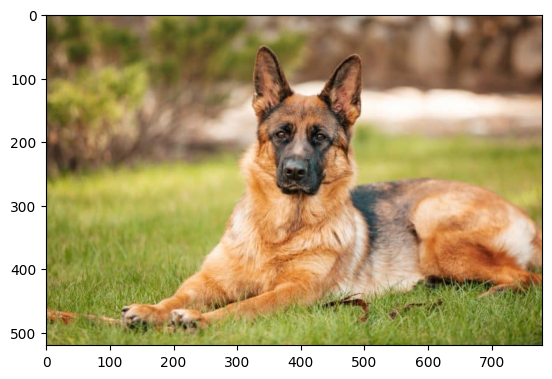

In [4]:
print(image.dtype)
print(image.shape)
# display the array of pixels as an image
pyplot.imshow(image)
pyplot.show()

Padded Img array shape :  (522, 782, 3)


100%|███████████████████████████████████████████████████████████████████████████████| 520/520 [00:02<00:00, 188.81it/s]


(520, 780)


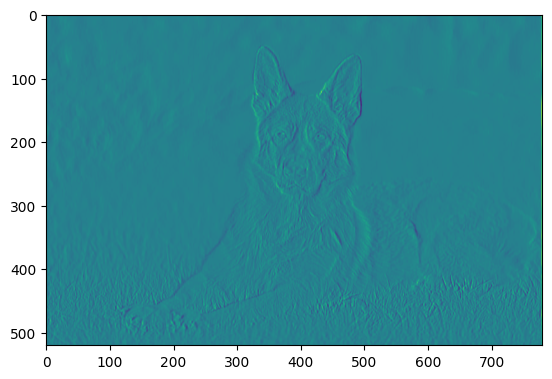

In [5]:


from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math



img_array = mpimg.imread('dog.jpg')

fltr_len = 3

# vertical sobel filter
_filter = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# horizontal sobel filter
_filter = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

kernel = np.repeat(_filter[None, :], 3, axis=0)
transposed_kernel = np.transpose(kernel)


# print(kernel, kernel.shape)
# print(transposed_kernel, transposed_kernel.shape)

result = np.zeros(img_array.shape[:2])

image_array = np.pad(img_array, ((1,1), (1,1), (0,0)))

img_row_len, img_col_len, img_depth_len = image_array.shape

print("Padded Img array shape : ", image_array.shape)

for i in tqdm(range(img_row_len - fltr_len + 1)):
    for j in range(img_col_len - fltr_len + 1):
        img_slice = image_array[i:i+fltr_len, j:j+fltr_len]
        # print(i, i+ fltr_len, j, j+ fltr_len)
        # print(img_slice)
        # print(img_slice.shape)
        result[i,j] = np.sum(np.multiply(img_slice, transposed_kernel))
        
#         print("Img Slice Shape : ", img_slice.shape)
#         print("Img Slice : ", img_slice)
#         print(matrix.shape)
#         print(matrix)
#         # result[i, j] = np.sum(np.multiply(img_array[i:i+fltr_len, j:j+fltr_len], _filter))
#         print("++++++++++++++++++++++++")
#     print("*******************************************")
print(result.shape)

plt.imshow(result)
plt.show()

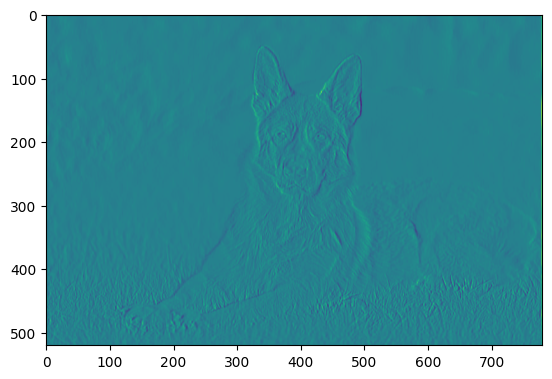

In [7]:
plt.imshow(result)
plt.show()

In [8]:
import mnist

In [9]:
train_images = mnist.train_images()[:1000]
train_labels = mnist.train_labels()[:1000]
test_images = mnist.test_images()[:1000]
test_labels = mnist.test_labels()[:1000]

In [11]:
train_images.shape

(1000, 28, 28)

In [12]:
img1 = train_images[1]

In [13]:
img1.shape

(28, 28)

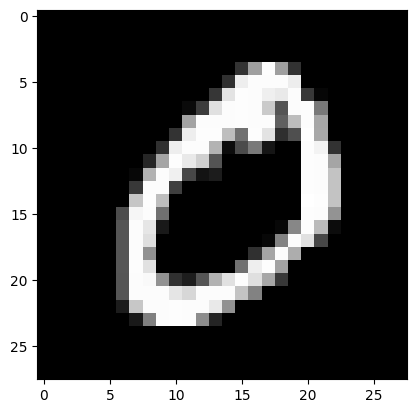

In [14]:
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)  

In [15]:
img1.shape

(28, 28)

In [16]:
def conv2d(img_array, _filter, padding, stride):

    img_row_len, img_col_len = img_array.shape
    fltr_len = _filter.shape[0] # filter is a square matrix as row len == col len
    
    output_row_size = ((img_row_len - fltr_len + 2*padding)/stride) + 1  # if decimal then invalid padding / filter / stride
    output_col_size = ((img_col_len - fltr_len + 2*padding)/stride) + 1
    
    if (output_row_size != int(output_row_size)) or (output_col_size != int(output_col_size)):
        raise Exception("row and col size should be an integers not float")
        
    output_row_size = int(output_row_size)
    output_col_size = int(output_col_size)

    result = np.zeros((output_row_size, output_col_size))

    for i in tqdm(range(img_row_len - fltr_len + 1)):
        for j in range(img_col_len - fltr_len + 1):
            result[i, j] = np.sum(np.multiply(img_array[i:i+fltr_len, j:j+fltr_len], _filter))
    return result

100%|████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 5908.75it/s]

(28, 28)


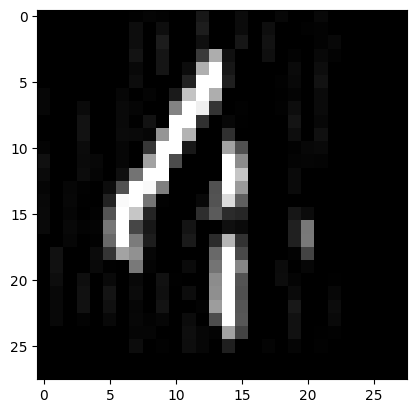

In [19]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math


# def rgb2gray(rgb):
#     return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = mpimg.imread('four.jpg')

filter_sharpen = np.array([
    [-1, 1, 0],
    [-1, 1, 0],
    [-1, 1, 0]
])

padding = 1

stride = 1

output_img_array = conv2d(img, filter_sharpen, padding, stride)
print(output_img_array.shape)
plt.imshow(output_img_array, cmap='gray', vmin=0, vmax=255)

100%|████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 4410.95it/s]

(28, 28)


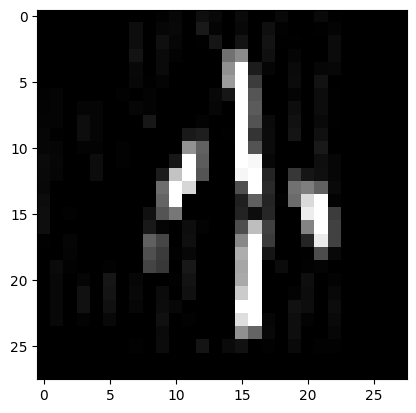

In [20]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math


# def rgb2gray(rgb):
#     return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = mpimg.imread('four.jpg')

filter_sharpen = np.array([
    [0, 1, -1],
    [0, 1, -1],
    [0, 1, -1]
])

padding = 1

stride = 1

output_img_array = conv2d(img, filter_sharpen, padding, stride)
print(output_img_array.shape)
plt.imshow(output_img_array, cmap='gray', vmin=0, vmax=255)

In [1]:
def rgb2gray(rgb):
    return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])

In [6]:
from matplotlib import image
from matplotlib import pyplot as plt
# load image as pixel array
image = image.imread('cat.jpg')


In [7]:
import numpy as np
grey_array = rgb2gray(image)

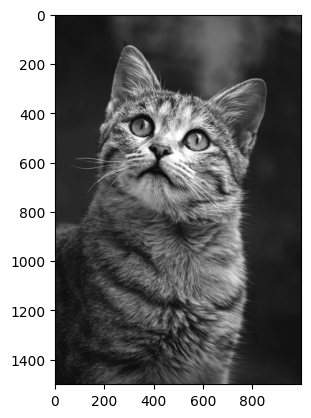

In [8]:
plt.imshow(grey_array, cmap='gray', vmin=0, vmax=255)

In [27]:

def conv2d(img_array, _filter, padding, stride):

    img_row_len, img_col_len = img_array.shape
    fltr_len = _filter.shape[0] # filter is a square matrix as row len == col len
    
    output_row_size = ((img_row_len - fltr_len + 2*padding)/stride) + 1  # if decimal then invalid padding / filter / stride
    output_col_size = ((img_col_len - fltr_len + 2*padding)/stride) + 1
    
    if (output_row_size != int(output_row_size)) or (output_col_size != int(output_col_size)):
        raise Exception("row and col size should be an integers not float")
        
    output_row_size = int(output_row_size)
    output_col_size = int(output_col_size)

    result = np.zeros((output_row_size, output_col_size))

    for i in tqdm(range(img_row_len - fltr_len + 1)):
        for j in range(img_col_len - fltr_len + 1):
            result[i, j] = np.sum(np.multiply(img_array[i:i+fltr_len, j:j+fltr_len], _filter))
    return result

def calculate_output_size_after_pooling(input_size, pool_size):
    remainder, quotient = input_size % pool_size[0], input_size // pool_size[0]
    if quotient >= 1:
        if remainder > 0:
            output_size = quotient + 1
        else:
            output_size = quotient
    else:
        output_size = 1
    return output_size

def pooling(img_array, pool_size, mode="max"):
    row, col = img_array.shape
    output_row_size = calculate_output_size_after_pooling(row, pool_size)
    output_col_size = calculate_output_size_after_pooling(col, pool_size)
    print(output_row_size, output_col_size)
    result = np.zeros((output_row_size, output_col_size))

    for i in tqdm(range(output_row_size)):
        for j in range(output_col_size):
            start_row = pool_size[0]*i
            end_row = pool_size[0]*i+pool_size[0]
            start_col = pool_size[1]*j
            end_col = pool_size[1]*j+pool_size[1]
            # print(img_array[start_row:end_row, start_col:end_col])
            # print("-------", start_row, end_row, start_col, end_col)
            if mode == "max":
                result[i, j] = np.max(img_array[start_row:end_row, start_col:end_col])
            elif mode == "average":
                result[i, j] = np.mean(img_array[start_row:end_row, start_col:end_col])
        # print("+++++++++")

            # print(np.max(img_array[i:i+2, j:j+2]))
            
    return result

In [30]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math
from PIL import Image


# def rgb2gray(rgb):
#     return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = mpimg.imread('cat.jpg')
img = rgb2gray(img)

filters = np.array([[[-1, 1, 0],[-1, 1, 0],[-1, 1, 0]],[[0, 1, -1],[0, 1, -1],[0, 1, -1]], [[-1, -1, -1],[1, 1, 1],[0, 0, 0]], [[0, 0, 0],[1, 1, 1],[-1, -1, -1]]])
# print(filter_sharpen)

padding = 1

stride = 1
pool_size = (2,2)

for i in range(4):
    # print(_filter)
    img_array = conv2d(img, filters[i], padding, stride)
    print(img_array.shape)
    im = Image.fromarray(img_array)
    im.save(f"exps2/cat_filtered_{i}.tif")
    pooled_array = pooling(img_array, pool_size, mode="average")
    print(pooled_array.shape)
    im = Image.fromarray(pooled_array)
    im.save(f"exps2/cat_pooled_{i}.tif")
    
    # plt.imshow(output_img_array, cmap='gray', vmin=0, vmax=255)

100%|█████████████████████████████████████████████████████████████████████████████| 1498/1498 [00:07<00:00, 207.78it/s]


(1500, 1000)
750 500


100%|███████████████████████████████████████████████████████████████████████████████| 750/750 [00:01<00:00, 378.98it/s]


(750, 500)


100%|█████████████████████████████████████████████████████████████████████████████| 1498/1498 [00:07<00:00, 190.84it/s]


...

(750, 500)


100%|█████████████████████████████████████████████████████████████████████████████| 1498/1498 [00:08<00:00, 178.42it/s]


(1500, 1000)
750 500


100%|███████████████████████████████████████████████████████████████████████████████| 750/750 [00:02<00:00, 357.45it/s]

(750, 500)


In [33]:
img_array.flatten().shape

(1500000,)

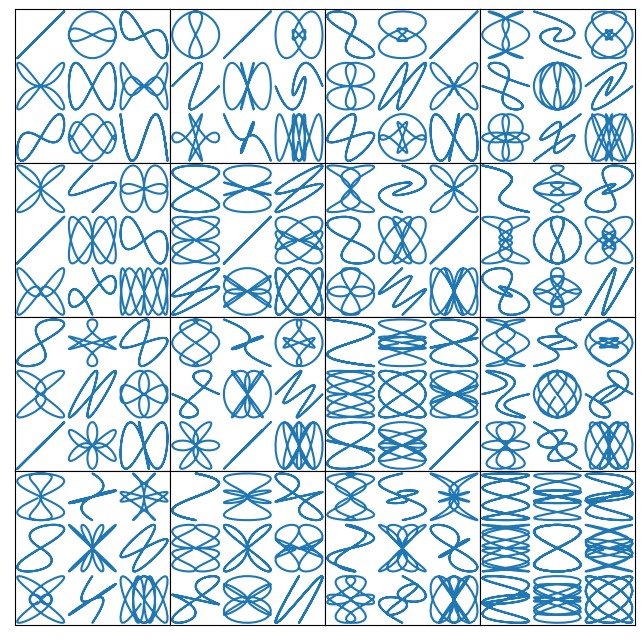

In [9]:
def squiggle_xy(a, b, c, d, i=np.arange(0.0, 2*np.pi, 0.05)):
    return np.sin(i*a)*np.cos(i*b), np.sin(i*c)*np.cos(i*d)

fig = plt.figure(figsize=(8, 8), constrained_layout=False)
outer_grid = fig.add_gridspec(4, 4, wspace=0, hspace=0)

for a in range(4):
    for b in range(4):
        # gridspec inside gridspec
        inner_grid = outer_grid[a, b].subgridspec(3, 3, wspace=0, hspace=0)
        axs = inner_grid.subplots()  # Create all subplots for the inner grid.
        for (c, d), ax in np.ndenumerate(axs):
            ax.plot(*squiggle_xy(a + 1, b + 1, c + 1, d + 1))
            ax.set(xticks=[], yticks=[])

# show only the outside spines
for ax in fig.get_axes():
    ss = ax.get_subplotspec()
    ax.spines.top.set_visible(ss.is_first_row())
    ax.spines.bottom.set_visible(ss.is_last_row())
    ax.spines.left.set_visible(ss.is_first_col())
    ax.spines.right.set_visible(ss.is_last_col())

plt.show()

NameError: name 'annotate_axes' is not defined

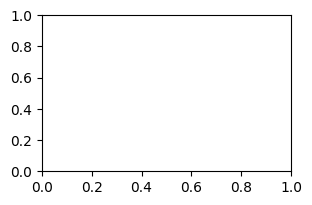

In [10]:
fig = plt.figure(figsize=(5.5, 3.5), layout="constrained")
spec = fig.add_gridspec(ncols=2, nrows=2)

ax0 = fig.add_subplot(spec[0, 0])
annotate_axes(ax0, 'ax0')

ax1 = fig.add_subplot(spec[0, 1])
annotate_axes(ax1, 'ax1')

ax2 = fig.add_subplot(spec[1, 0])
annotate_axes(ax2, 'ax2')

ax3 = fig.add_subplot(spec[1, 1])
annotate_axes(ax3, 'ax3')

fig.suptitle('Manually added subplots using add_gridspec')

Text(0.5, 0.98, 'plt.subplots()')

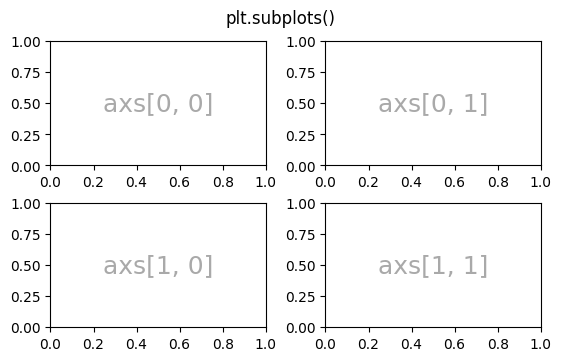

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(5.5, 3.5),
                        layout="constrained")
# add an artist, in this case a nice label in the middle...
for row in range(2):
    for col in range(2):
        axs[row, col].annotate(f'axs[{row}, {col}]', (0.5, 0.5),
                               transform=axs[row, col].transAxes,
                               ha='center', va='center', fontsize=18,
                               color='darkgrey')
fig.suptitle('plt.subplots()')